In [ ]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Sample text corpus
text_data = [
    "The movie was fantastic and amazing!",
    "I did not like the film. It was boring.",
    "The actors performed well but the story was predictable.",
    "An excellent movie with a brilliant script!",
    "The film was too long and dull."
]


##  One-Hot Encoding

In [ ]:
from sklearn.preprocessing import LabelBinarizer

In [ ]:
# Tokenizing each sentence
tokenized_texts = [word_tokenize(sentence.lower()) for sentence in text_data]

# Flattening unique words
unique_words = list(set(word for sentence in tokenized_texts for word in sentence))


In [ ]:
# Creating One-Hot Encoding
encoder = LabelBinarizer()
one_hot_encoded = encoder.fit_transform(unique_words)

In [ ]:
# Display
one_hot_df = pd.DataFrame(one_hot_encoded, index=unique_words, columns=encoder.classes_)
print("One-Hot Encoding:")
print(one_hot_df.head())

One-Hot Encoding:
           !  .  a  actors  amazing  an  and  boring  brilliant  but  ...  \
amazing    0  0  0       0        1   0    0       0          0    0  ...   
brilliant  0  0  0       0        0   0    0       0          1    0  ...   
like       0  0  0       0        0   0    0       0          0    0  ...   
actors     0  0  0       1        0   0    0       0          0    0  ...   
i          0  0  0       0        0   0    0       0          0    0  ...   

           not  performed  predictable  script  story  the  too  was  well  \
amazing      0          0            0       0      0    0    0    0     0   
brilliant    0          0            0       0      0    0    0    0     0   
like         0          0            0       0      0    0    0    0     0   
actors       0          0            0       0      0    0    0    0     0   
i            0          0            0       0      0    0    0    0     0   

           with  
amazing       0  
brilliant     

## Bag of Words (BOW)

In [ ]:
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(text_data)

In [ ]:
# Convert to DataFrame for better readability
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("Bag of Words Representation:")
print(bow_df)

Bag of Words Representation:
   actors  amazing  an  and  boring  brilliant  but  did  dull  excellent  \
0       0        1   0    1       0          0    0    0     0          0   
1       0        0   0    0       1          0    0    1     0          0   
2       1        0   0    0       0          0    1    0     0          0   
3       0        0   1    0       0          1    0    0     0          1   
4       0        0   0    1       0          0    0    0     1          0   

   ...  not  performed  predictable  script  story  the  too  was  well  with  
0  ...    0          0            0       0      0    1    0    1     0     0  
1  ...    1          0            0       0      0    1    0    1     0     0  
2  ...    0          1            1       0      1    2    0    1     1     0  
3  ...    0          0            0       1      0    0    0    0     0     1  
4  ...    0          0            0       0      0    1    1    1     0     0  

[5 rows x 26 columns]


<ipython-input-39-0e9de374b91e>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bow_word_freq_df['word'][:10], y=bow_word_freq_df['count'][:10], palette="viridis")


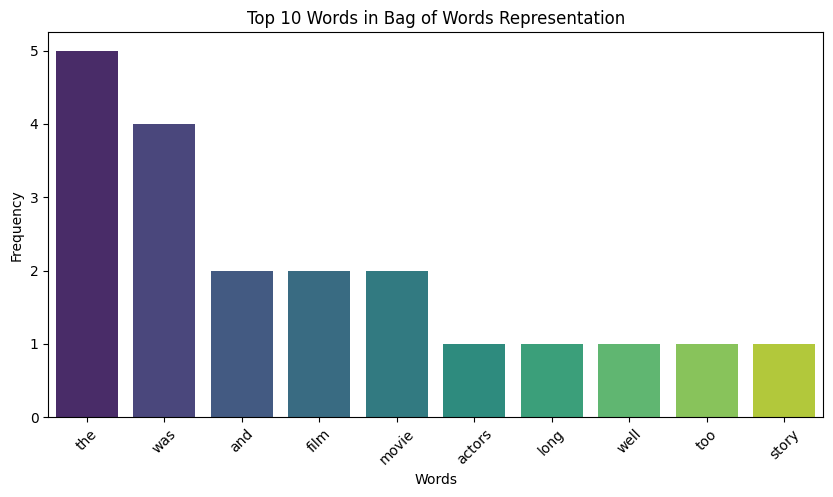

In [ ]:
# Visualizing Top 10 Words
bow_word_freq = np.sum(bow_matrix.toarray(), axis=0)  # Sum occurrences of each word
bow_word_freq_df = pd.DataFrame({'word': vectorizer.get_feature_names_out(), 'count': bow_word_freq})
bow_word_freq_df = bow_word_freq_df.sort_values(by='count', ascending=False)

# Plot bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=bow_word_freq_df['word'][:10], y=bow_word_freq_df['count'][:10], palette="viridis")
plt.title("Top 10 Words in Bag of Words Representation")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

## N-Grams (Bigrams)

In [ ]:
vectorizer_bigram = CountVectorizer(ngram_range=(2,2))  # Bigrams

bigram_matrix = vectorizer_bigram.fit_transform(text_data)


In [ ]:
# Convert to DataFrame
bigram_df = pd.DataFrame(bigram_matrix.toarray(), columns=vectorizer_bigram.get_feature_names_out())

In [ ]:
print("Bigram Representation:")
print(bigram_df)

Bigram Representation:
   actors performed  an excellent  and amazing  and dull  brilliant script  \
0                 0             0            1         0                 0   
1                 0             0            0         0                 0   
2                 1             0            0         0                 0   
3                 0             1            0         0                 1   
4                 0             0            0         1                 0   

   but the  did not  excellent movie  fantastic and  film it  ...  the film  \
0        0        0                0              1        0  ...         0   
1        0        1                0              0        1  ...         1   
2        1        0                0              0        0  ...         0   
3        0        0                1              0        0  ...         0   
4        0        0                0              0        0  ...         1   

   the movie  the story  too long

## ## N-Grams (Trigrams)

In [ ]:
vectorizer_trigram = CountVectorizer(ngram_range=(3,3))  # Trigrams

trigram_matrix = vectorizer_trigram.fit_transform(text_data)

In [ ]:
# Convert to DataFrame
trigram_df = pd.DataFrame(trigram_matrix.toarray(), columns=vectorizer_trigram.get_feature_names_out())

In [ ]:
print("Trigram Representation:")
print(trigram_df)


Trigram Representation:
   actors performed well  an excellent movie  but the story  did not like  \
0                      0                   0              0             0   
1                      0                   0              0             1   
2                      1                   0              1             0   
3                      0                   1              0             0   
4                      0                   0              0             0   

   excellent movie with  fantastic and amazing  film it was  film was too  \
0                     0                      1            0             0   
1                     0                      0            1             0   
2                     0                      0            0             0   
3                     1                      0            0             0   
4                     0                      0            0             1   

   it was boring  like the film  ...  the actors p

## TF-IDF (Term Frequency-Inverse Document Frequency)

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(text_data)

In [ ]:
# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [ ]:
print("TF-IDF Representation:")
print(tfidf_df)

TF-IDF Representation:
     actors   amazing        an       and    boring  brilliant       but  \
0  0.000000  0.504008  0.000000  0.406631  0.000000   0.000000  0.000000   
1  0.000000  0.000000  0.000000  0.000000  0.398862   0.000000  0.000000   
2  0.363049  0.000000  0.000000  0.000000  0.000000   0.000000  0.363049   
3  0.000000  0.000000  0.420669  0.000000  0.000000   0.420669  0.000000   
4  0.000000  0.000000  0.000000  0.363117  0.000000   0.000000  0.000000   

        did      dull  excellent  ...       not  performed  predictable  \
0  0.000000  0.000000   0.000000  ...  0.000000   0.000000     0.000000   
1  0.398862  0.000000   0.000000  ...  0.398862   0.000000     0.000000   
2  0.000000  0.000000   0.000000  ...  0.000000   0.363049     0.363049   
3  0.000000  0.000000   0.420669  ...  0.000000   0.000000     0.000000   
4  0.000000  0.450075   0.000000  ...  0.000000   0.000000     0.000000   

     script     story       the       too       was      well      wi

<ipython-input-40-9513752d7677>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tfidf_word_scores_df['word'][:10], y=tfidf_word_scores_df['score'][:10], palette="magma")


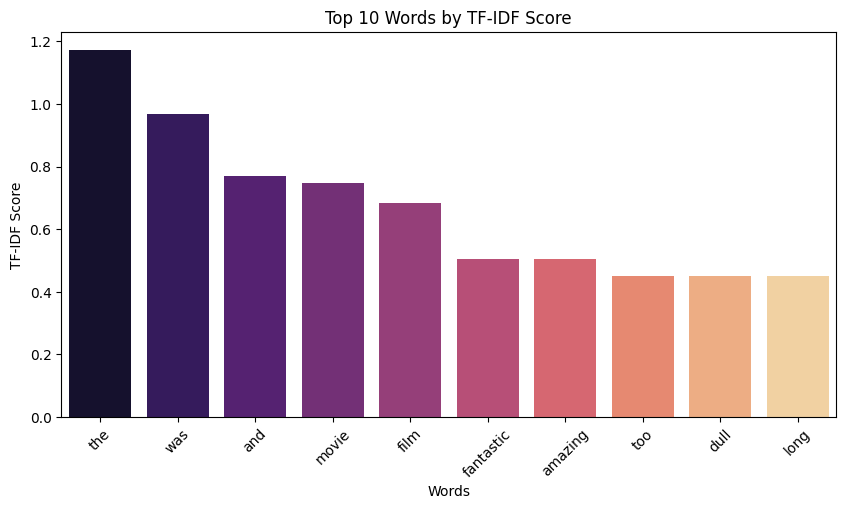

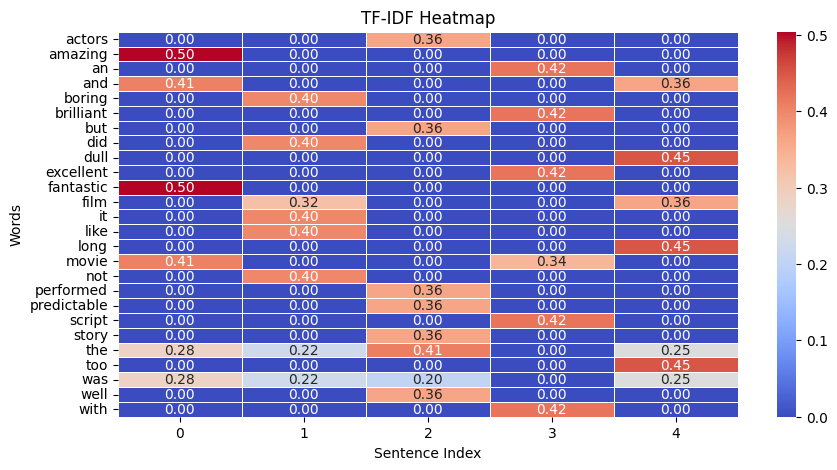

In [ ]:
# Visualizing Top 10 TF-IDF Scores
tfidf_word_scores = np.sum(tfidf_matrix.toarray(), axis=0)
tfidf_word_scores_df = pd.DataFrame({'word': tfidf_vectorizer.get_feature_names_out(), 'score': tfidf_word_scores})
tfidf_word_scores_df = tfidf_word_scores_df.sort_values(by='score', ascending=False)

# Plot bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=tfidf_word_scores_df['word'][:10], y=tfidf_word_scores_df['score'][:10], palette="magma")
plt.title("Top 10 Words by TF-IDF Score")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)
plt.show()

# TF-IDF Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(tfidf_df.T, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("TF-IDF Heatmap")
plt.xlabel("Sentence Index")
plt.ylabel("Words")
plt.show()

###  Visualizing Word Frequency

In [ ]:
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()

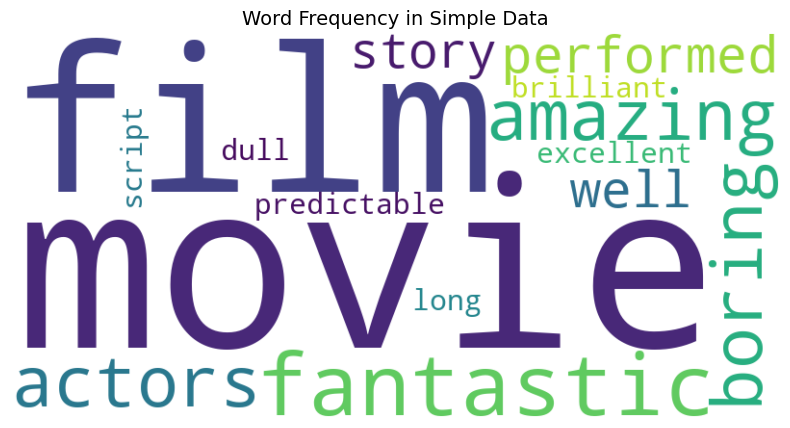

In [ ]:
# Flatten words for visualization
words_flattened = [word for sentence in tokenized_texts for word in sentence]
plot_wordcloud(words_flattened, "Word Frequency in Simple Data")

# IMDB Dataset

In [ ]:
# Load IMDB dataset using a different source or method:
# Option 1: Load the dataset using huggingface datasets
!pip install datasets

In [ ]:
from datasets import load_dataset
dataset = load_dataset("imdb")
df = dataset["train"].to_pandas()

In [ ]:
# Display first few rows
print(df.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [ ]:
# Extract reviews
reviews = df['text'][:10]  # Taking first 10 reviews for simplicity

In [ ]:
# One hot encoding

# Tokenizing first 10 reviews
tokenized_reviews = [word_tokenize(sentence.lower()) for sentence in reviews]
unique_words_reviews = list(set(word for sentence in tokenized_reviews for word in sentence))

# Creating One-Hot Encoding
one_hot_encoded_reviews = encoder.fit_transform(unique_words_reviews)

# Display
one_hot_reviews_df = pd.DataFrame(one_hot_encoded_reviews, index=unique_words_reviews, columns=encoder.classes_)
print("One-Hot Encoding on IMDB Data:")
print(one_hot_reviews_df.head())


One-Hot Encoding on IMDB Data:
             !  &  '  ''  'd  'll  'love  're  's  've  ...  written  wrong  \
staple       0  0  0   0   0    0      0    0   0    0  ...        0      0   
strikes      0  0  0   0   0    0      0    0   0    0  ...        0      0   
stinker      0  0  0   0   0    0      0    0   0    0  ...        0      0   
interesting  0  0  0   0   0    0      0    0   0    0  ...        0      0   
rhythymed    0  0  0   0   0    0      0    0   0    0  ...        0      0   

             wrote  years  yeesh  yellow  york  you  young  your  
staple           0      0      0       0     0    0      0     0  
strikes          0      0      0       0     0    0      0     0  
stinker          0      0      0       0     0    0      0     0  
interesting      0      0      0       0     0    0      0     0  
rhythymed        0      0      0       0     0    0      0     0  

[5 rows x 923 columns]


In [ ]:
# Bag of Words


bow_vectorizer = CountVectorizer()
bow_matrix_reviews = bow_vectorizer.fit_transform(reviews)

# Convert to DataFrame
bow_reviews_df = pd.DataFrame(bow_matrix_reviews.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("Bag of Words on IMDB Reviews:")
print(bow_reviews_df)


Bag of Words on IMDB Reviews:
   10  17  1967  20  40  _is_  ability  about  above  absolutely  ...  \
0   0   0     1   0   1     0        0      4      0           0  ...   
1   0   1     0   0   0     0        1      0      0           0  ...   
2   0   0     0   0   0     0        0      0      0           0  ...   
3   1   0     0   0   0     0        0      0      0           0  ...   
4   0   0     0   0   0     0        0      1      0           0  ...   
5   0   0     0   0   0     0        0      0      0           0  ...   
6   0   0     0   0   0     0        0      1      0           0  ...   
7   0   0     0   0   0     0        0      1      0           1  ...   
8   0   0     0   1   0     1        0      0      1           0  ...   
9   0   0     0   0   0     0        0      0      0           0  ...   

   written  wrong  wrote  years  yeesh  yellow  york  you  young  your  
0        0      0      0      1      0       3     0    0      1     0  
1        0      0   

<ipython-input-41-5d6f5fba7e8a>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bow_word_freq_reviews_df['word'][:10], y=bow_word_freq_reviews_df['count'][:10], palette="coolwarm")


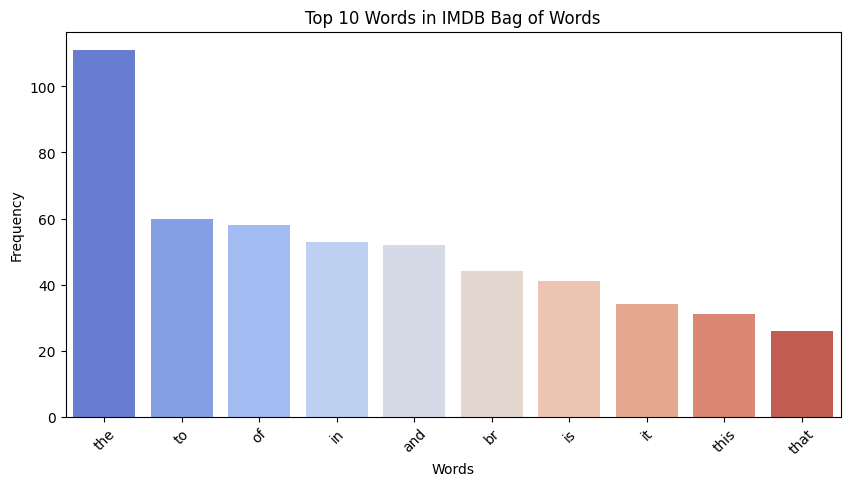

In [ ]:
# Top 10 Words
bow_word_freq_reviews = np.sum(bow_matrix_reviews.toarray(), axis=0)
bow_word_freq_reviews_df = pd.DataFrame({'word': bow_vectorizer.get_feature_names_out(), 'count': bow_word_freq_reviews})
bow_word_freq_reviews_df = bow_word_freq_reviews_df.sort_values(by='count', ascending=False)

# Plot bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=bow_word_freq_reviews_df['word'][:10], y=bow_word_freq_reviews_df['count'][:10], palette="coolwarm")
plt.title("Top 10 Words in IMDB Bag of Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# N-grams

bigram_vectorizer = CountVectorizer(ngram_range=(2,2))  # Bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3,3))  # Trigrams

bigram_matrix_reviews = bigram_vectorizer.fit_transform(reviews)
trigram_matrix_reviews = trigram_vectorizer.fit_transform(reviews)

# Convert to DataFrame
bigram_reviews_df = pd.DataFrame(bigram_matrix_reviews.toarray(), columns=bigram_vectorizer.get_feature_names_out())
trigram_reviews_df = pd.DataFrame(trigram_matrix_reviews.toarray(), columns=trigram_vectorizer.get_feature_names_out())

print("Bigram Representation on IMDB:")
print(bigram_reviews_df)

print("Trigram Representation on IMDB:")
print(trigram_reviews_df)


Bigram Representation on IMDB:
   17 that  1967 also  20 may  40 years  _is_ real  ability to  about am  \
0        0          1       0         1          0           0         1   
1        1          0       0         0          0           1         0   
2        0          0       0         0          0           0         0   
3        0          0       0         0          0           0         0   
4        0          0       0         0          0           0         0   
5        0          0       0         0          0           0         0   
6        0          0       0         0          0           0         0   
7        0          0       0         0          0           0         0   
8        0          0       1         0          1           0         0   
9        0          0       0         0          0           0         0   

   about certain  about legend  about life  ...  you must  you noticed  \
0              1             0           1  ...         0 

In [ ]:
# TF-IDF


tfidf_vectorizer_reviews = TfidfVectorizer()
tfidf_matrix_reviews = tfidf_vectorizer_reviews.fit_transform(reviews)

# Convert to DataFrame
tfidf_reviews_df = pd.DataFrame(tfidf_matrix_reviews.toarray(), columns=tfidf_vectorizer_reviews.get_feature_names_out())
print("TF-IDF Representation on IMDB:")
print(tfidf_reviews_df)


TF-IDF Representation on IMDB:
         10        17      1967        20        40      _is_   ability  \
0  0.000000  0.000000  0.057531  0.000000  0.057531  0.000000  0.000000   
1  0.000000  0.069931  0.000000  0.000000  0.000000  0.000000  0.069931   
2  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
3  0.105083  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
5  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
6  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
7  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
8  0.000000  0.000000  0.000000  0.038294  0.000000  0.038294  0.000000   
9  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

      about     above  absolutely  ...   written     wrong     wrote  \
0  0.152165  0.000000    0.000000  ...  0.000000  0.000000  0.000000   

<ipython-input-42-5205967c0589>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tfidf_word_scores_reviews_df['word'][:10], y=tfidf_word_scores_reviews_df['score'][:10], palette="viridis")


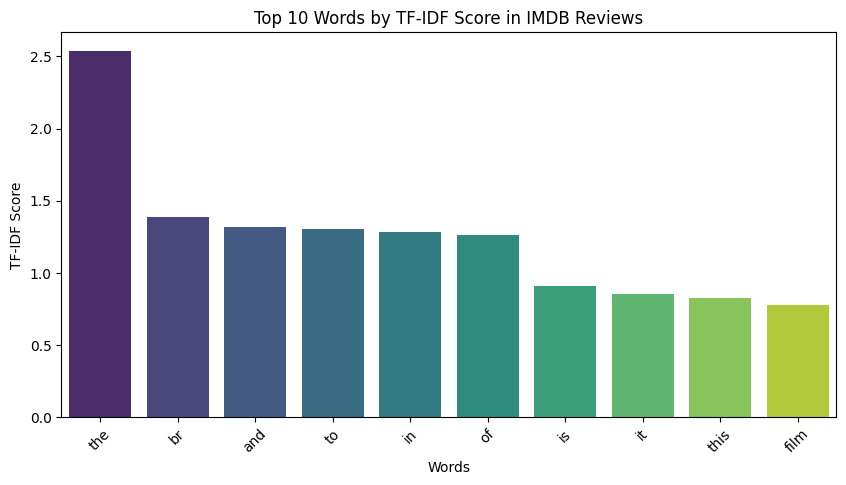

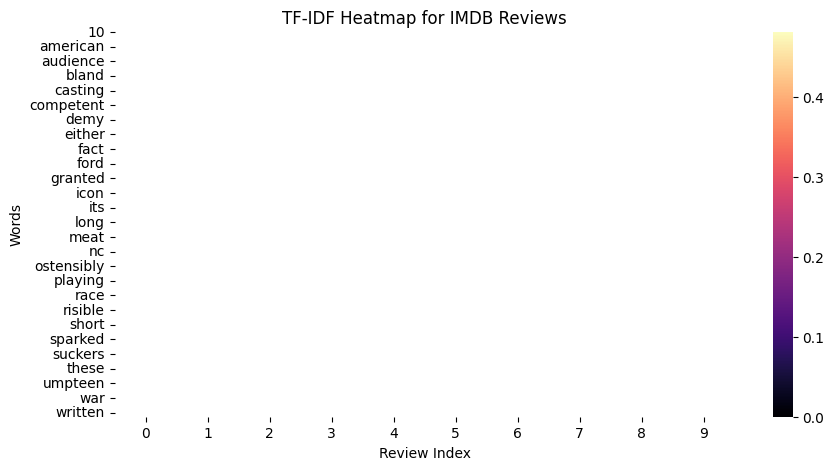

In [ ]:
# Top 10 Words
tfidf_word_scores_reviews = np.sum(tfidf_matrix_reviews.toarray(), axis=0)
tfidf_word_scores_reviews_df = pd.DataFrame({'word': tfidf_vectorizer_reviews.get_feature_names_out(), 'score': tfidf_word_scores_reviews})
tfidf_word_scores_reviews_df = tfidf_word_scores_reviews_df.sort_values(by='score', ascending=False)

# Plot bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=tfidf_word_scores_reviews_df['word'][:10], y=tfidf_word_scores_reviews_df['score'][:10], palette="viridis")
plt.title("Top 10 Words by TF-IDF Score in IMDB Reviews")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)
plt.show()

# TF-IDF Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(tfidf_reviews_df.T, cmap="magma", annot=False, fmt=".2f", linewidths=0.5)
plt.title("TF-IDF Heatmap for IMDB Reviews")
plt.xlabel("Review Index")
plt.ylabel("Words")
plt.show()

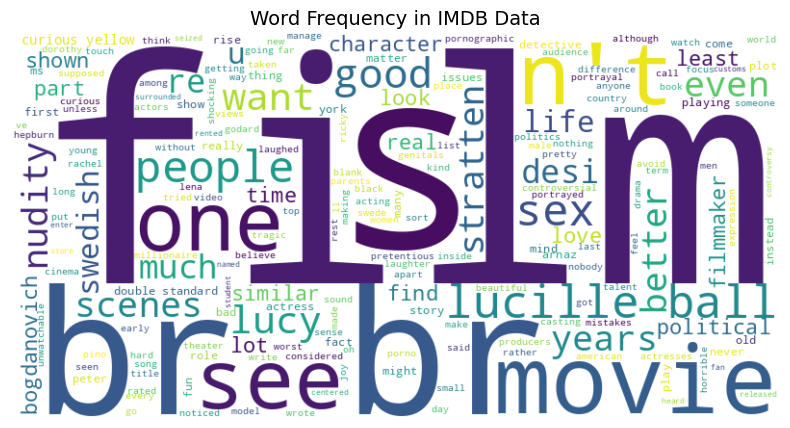

In [ ]:
#  Word Cloud for IMDB Data

words_flattened_reviews = [word for sentence in tokenized_reviews for word in sentence]
plot_wordcloud(words_flattened_reviews, "Word Frequency in IMDB Data")
